First, we need to install OpenCV if it's not already installed. Then, we'll import the library.

In [1]:
!pip install opencv-python-headless

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Now, let's load an image. Please replace `'path/to/your/image.jpg'` with the actual path to your image file. You can upload an image to your Colab environment or use a publicly accessible URL.

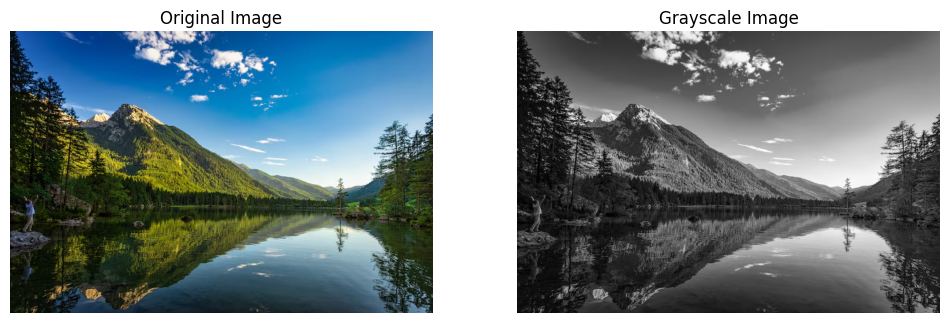

In [3]:
# Load the image
# Replace 'path/to/your/image.jpg' with your image file path
image_path = '/content/forest image.avif' # Example: '/content/my_image.png'

# Try to read the image. If it fails, display an error.
try:
    original_image = cv2.imread(image_path)
    if original_image is None:
        raise FileNotFoundError("Image not found or unable to load. Please check the path.")

    # OpenCV loads images in BGR format, matplotlib expects RGB
    image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    # Convert the image to grayscale
    gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

    # Display the original and grayscale images
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')
    plt.show()

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please upload an image or provide a valid path for 'image_path'.")
    original_image = None # Ensure original_image is None if loading failed
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    original_image = None

Now, let's perform image segmentation using thresholding. Thresholding converts a grayscale image into a binary image, where pixels are either black or white, based on a comparison with a threshold value.

### 1. Global Thresholding (Manual Threshold)

In global thresholding, a single threshold value is applied to the entire image. You can adjust the `threshold_value` below to see different segmentation results. Pixels with intensity values greater than the threshold are set to `max_value`, and others are set to 0 (or vice-versa depending on the `thresh_type`).

Common `thresh_type` values:
- `cv2.THRESH_BINARY`: If pixel intensity > `threshold_value`, set to `max_value`, else 0.
- `cv2.THRESH_BINARY_INV`: Inverse of `THRESH_BINARY`.

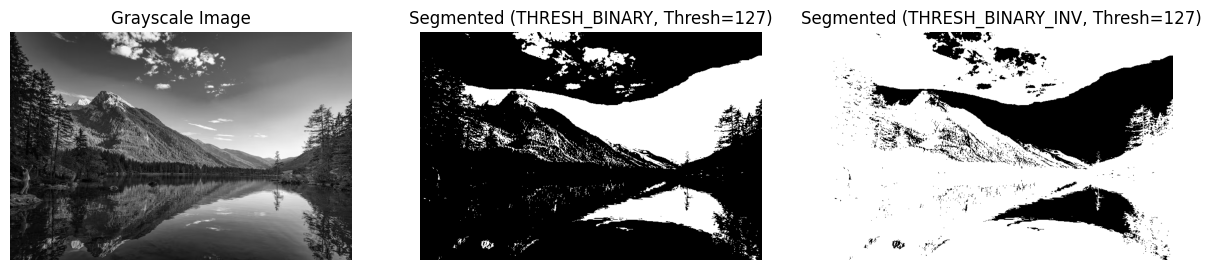

In [4]:
if original_image is not None:
    # Define your threshold value (0-255)
    threshold_value = 127  # You can change this value
    max_value = 255      # Maximum intensity value for segmented pixels

    # Apply simple global thresholding
    # THRESH_BINARY: pixels > threshold_value become max_value, others become 0
    ret, segmented_image_binary = cv2.threshold(gray_image, threshold_value, max_value, cv2.THRESH_BINARY)

    # THRESH_BINARY_INV: pixels > threshold_value become 0, others become max_value
    ret_inv, segmented_image_binary_inv = cv2.threshold(gray_image, threshold_value, max_value, cv2.THRESH_BINARY_INV)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(segmented_image_binary, cmap='gray')
    plt.title(f'Segmented (THRESH_BINARY, Thresh={threshold_value})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(segmented_image_binary_inv, cmap='gray')
    plt.title(f'Segmented (THRESH_BINARY_INV, Thresh={threshold_value})')
    plt.axis('off')
    plt.show()
else:
    print("Cannot perform segmentation as no image was loaded.")

### 2. Otsu's Thresholding (Automatic Threshold)

Otsu's method automatically calculates an optimal threshold value from the image histogram. It's often very effective when the image has a bimodal intensity distribution (i.e., clear foreground and background regions). This method eliminates the need to manually pick a `threshold_value`.

We combine `cv2.THRESH_BINARY` with `cv2.THRESH_OTSU`.

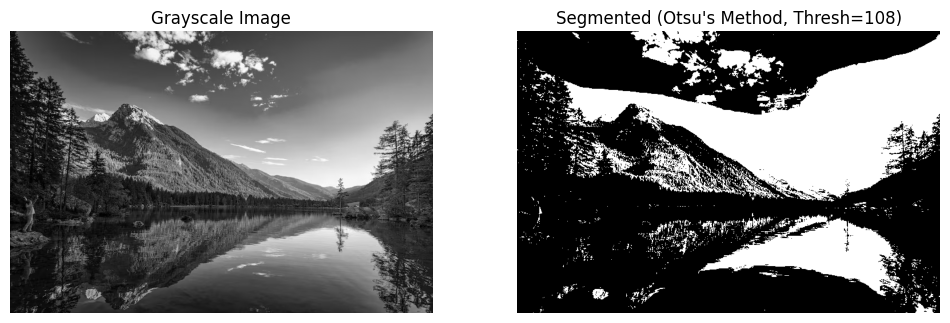

In [5]:
if original_image is not None:
    # Apply Otsu's thresholding
    # The function returns the optimal threshold value 'ret_otsu'
    ret_otsu, segmented_image_otsu = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(segmented_image_otsu, cmap='gray')
    plt.title(f'Segmented (Otsu\'s Method, Thresh={int(ret_otsu)})')
    plt.axis('off')
    plt.show()
else:
    print("Cannot perform Otsu's segmentation as no image was loaded.")

### 3. Adaptive Thresholding

Adaptive thresholding calculates a threshold value for *small regions* of the image. This method is useful when different parts of the image have different lighting conditions. You can specify the `block_size` (size of the neighborhood) and `C` (a constant subtracted from the mean or weighted mean).

- `cv2.ADAPTIVE_THRESH_MEAN_C`: The threshold value is the mean of the neighborhood area minus the constant `C`.
- `cv2.ADAPTIVE_THRESH_GAUSSIAN_C`: The threshold value is a weighted sum (Gaussian window) of the neighborhood area minus the constant `C`.

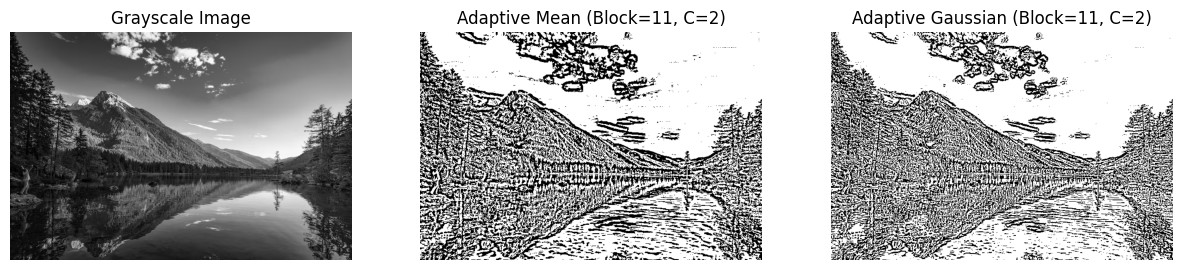

In [6]:
if original_image is not None:
    block_size = 11  # Size of a pixel neighborhood that is used to calculate the threshold value (must be odd)
    C = 2            # Constant subtracted from the mean or weighted mean

    # Adaptive Mean Thresholding
    adaptive_mean_thresh = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, block_size, C)

    # Adaptive Gaussian Thresholding
    adaptive_gaussian_thresh = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, block_size, C)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(adaptive_mean_thresh, cmap='gray')
    plt.title(f'Adaptive Mean (Block={block_size}, C={C})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(adaptive_gaussian_thresh, cmap='gray')
    plt.title(f'Adaptive Gaussian (Block={block_size}, C={C})')
    plt.axis('off')
    plt.show()
else:
    print("Cannot perform adaptive thresholding as no image was loaded.")